In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hellbuoy/online-retail-customer-clustering/OnlineRetail.csv


In [75]:
import numpy as np
import pandas as pd

In [76]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/hellbuoy/online-retail-customer-clustering/OnlineRetail.csv


In [77]:
df = pd.read_csv(
    "/kaggle/input/datasets/hellbuoy/online-retail-customer-clustering/OnlineRetail.csv",
    encoding="ISO-8859-1"
)

In [78]:
df. shape

(541909, 8)

In [79]:
df. head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [81]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [82]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [83]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [84]:
df[df["Quantity"] < 0][["InvoiceNo", "Quantity", "UnitPrice", "CustomerID"]].head(20)

,InvoiceNo,Quantity,UnitPrice,CustomerID
141,C536379,-1,27.50,14527.0
154,C536383,-1,4.65,15311.0
235,C536391,-12,1.65,17548.0
236,C536391,-24,0.29,17548.0
237,C536391,-24,0.29,17548.0
238,C536391,-24,0.29,17548.0
239,C536391,-12,3.45,17548.0
240,C536391,-12,1.65,17548.0
241,C536391,-24,1.65,17548.0
939,C536506,-6,4.25,17897.0


In [85]:
df["InvoiceNo"].str.startswith("C")

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: InvoiceNo, Length: 541909, dtype: bool

In [86]:
(
    df["InvoiceNo"].str.startswith("C")
    & (df["Quantity"] > 0)
).sum()

np.int64(0)

In [87]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [88]:
(
    (df["Quantity"] < 0) &
    (df["UnitPrice"] < 0)
).sum()

np.int64(0)

In [89]:
df[df["UnitPrice"] < 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
299983,A563186,B,Adjust bad debt,1,-11062.06,NaN
299984,A563187,B,Adjust bad debt,1,-11062.06,NaN


In [90]:
(df["InvoiceNo"].str.startswith("A")).sum()

np.int64(3)

In [91]:
df[df["InvoiceNo"].str.startswith("A")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,12-08-2011 14:50,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,12-08-2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,12-08-2011 14:52,-11062.06,NaN,United Kingdom


In [92]:
(
    (df["UnitPrice"] < 0)
    & (~df["InvoiceNo"].str.startswith("A"))
).sum()

np.int64(0)

In [93]:
(df["UnitPrice"] < 0).sum()

np.int64(2)

In [94]:
df[df["UnitPrice"] < 0][
    ["InvoiceNo", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,Description,Quantity,UnitPrice,CustomerID
299983,A563186,Adjust bad debt,1,-11062.06,NaN
299984,A563187,Adjust bad debt,1,-11062.06,NaN


In [95]:
(df["UnitPrice"] == 0).sum()

np.int64(2515)

In [96]:
df[df["UnitPrice"] == 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


In [97]:
df["CustomerID"].nunique()

4372

In [98]:
df["CustomerID"].isnull().sum()

np.int64(135080)

In [99]:
(df["CustomerID"].isnull().sum() / len(df)) * 100

np.float64(24.926694334288598)

In [100]:
df[df["CustomerID"].notnull()].shape

(406829, 8)

In [101]:
df_clean = df[df["CustomerID"].notnull()].copy()

In [102]:
df_clean.shape

(406829, 8)

In [103]:
(df_clean["Quantity"] < 0).sum()

np.int64(8905)

In [104]:
(
    (df_clean["Quantity"] < 0) &
    (df_clean["InvoiceNo"].str.startswith("C"))
).sum()

np.int64(8905)

In [105]:
df_sales = df_clean[df_clean["Quantity"] > 0].copy()

In [106]:
df_sales.shape

(397924, 8)

In [107]:
(df_sales["UnitPrice"] == 0).sum()

np.int64(40)

In [108]:
df_sales[df_sales["UnitPrice"] == 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,0.0,12647.0
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,0.0,16560.0
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,0.0,14911.0
47068,540372,22090,PAPER BUNTING RETROSPOT,24,0.0,13081.0
47070,540372,22553,PLASTERS IN TIN SKULLS,24,0.0,13081.0
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,0.0,15107.0
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,0.0,17560.0
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,0.0,13239.0
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,0.0,13113.0
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,0.0,14410.0


In [109]:
df_sales_clean = df_sales[df_sales["UnitPrice"] > 0].copy()

In [110]:
df_sales_clean.shape

(397884, 8)

In [111]:
df_sales_clean["InvoiceDate"].dtype

dtype('O')

In [112]:
df_sales_clean["InvoiceDate"] = pd.to_datetime(
    df_sales_clean["InvoiceDate"],
    dayfirst=True
)

In [113]:
df_sales_clean["InvoiceDate"].dtype

dtype('<M8[ns]')

In [114]:
df_sales_clean["InvoiceDate"].min()

Timestamp('2010-12-01 08:26:00')

In [115]:
df_sales_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [116]:
df_sales_clean.groupby("CustomerID")["InvoiceDate"].max()

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
                  ...        
18280.0   2011-03-07 09:52:00
18281.0   2011-06-12 10:53:00
18282.0   2011-12-02 11:43:00
18283.0   2011-12-06 12:02:00
18287.0   2011-10-28 09:29:00
Name: InvoiceDate, Length: 4338, dtype: datetime64[ns]

In [117]:
reference_date = df_sales_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

In [118]:
reference_date

Timestamp('2011-12-10 12:50:00')

In [119]:
last_purchase = df_sales_clean.groupby("CustomerID")["InvoiceDate"].max()

In [120]:
last_purchase.head()

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-12-07 15:52:00
12348.0   2011-09-25 13:13:00
12349.0   2011-11-21 09:51:00
12350.0   2011-02-02 16:01:00
Name: InvoiceDate, dtype: datetime64[ns]

In [121]:
reference_date - last_purchase

CustomerID
12346.0   326 days 02:49:00
12347.0     2 days 20:58:00
12348.0    75 days 23:37:00
12349.0    19 days 02:59:00
12350.0   310 days 20:49:00
                 ...       
18280.0   278 days 02:58:00
18281.0   181 days 01:57:00
18282.0     8 days 01:07:00
18283.0     4 days 00:48:00
18287.0    43 days 03:21:00
Name: InvoiceDate, Length: 4338, dtype: timedelta64[ns]

In [122]:
recency = (reference_date - last_purchase).dt.days

In [123]:
recency.head()

CustomerID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: InvoiceDate, dtype: int64

In [124]:
frequency = df_sales_clean.groupby("CustomerID")["InvoiceNo"].nunique()

In [125]:
frequency.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [126]:
df_sales_clean["Revenue"] = (
    df_sales_clean["Quantity"] * df_sales_clean["UnitPrice"]
)

In [127]:
df_sales_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [128]:
monetary = df_sales_clean.groupby("CustomerID")["Revenue"].sum()

In [129]:
monetary.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Revenue, dtype: float64

In [130]:
rfm = pd.concat([recency, frequency, monetary], axis=1)

In [131]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [132]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [133]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [134]:
rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary
CustomerID,,,
14646.0,2,73,280206.02
18102.0,1,60,259657.30
17450.0,8,46,194550.79
16446.0,1,2,168472.50
14911.0,1,201,143825.06
12415.0,24,21,124914.53
14156.0,10,55,117379.63
17511.0,3,31,91062.38
16029.0,39,63,81024.84


In [135]:
rfm.skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.324953
dtype: float64

In [136]:
np.log1p(rfm).head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [137]:
rfm_log = np.log1p(rfm)

In [138]:
rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


In [139]:
rfm_log.skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.393553
dtype: float64

In [140]:
from sklearn.preprocessing import StandardScaler

In [141]:
scaler = StandardScaler()

In [144]:
rfm_scaled = scaler.fit_transform(rfm_log)

In [145]:
rfm_scaled.shape

(4338, 3)

In [146]:
from sklearn.cluster import KMeans

In [147]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

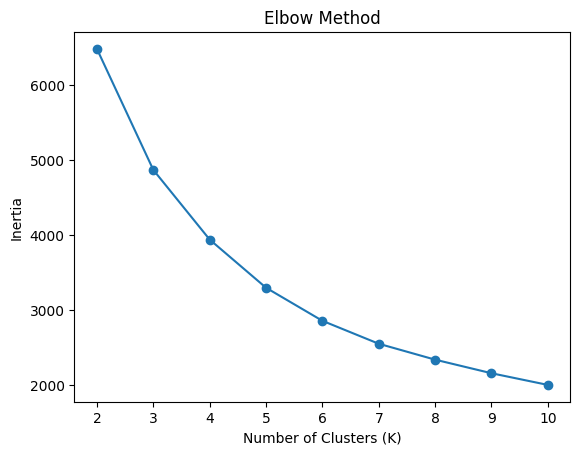

In [148]:
import matplotlib.pyplot as plt

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [149]:
list(zip(range(2, 11), inertia))

[(2, 6481.225323423518),
 (3, 4867.846645267566),
 (4, 3938.5099536013267),
 (5, 3295.976328792429),
 (6, 2855.011247001409),
 (7, 2548.9143244239413),
 (8, 2336.7775084644077),
 (9, 2155.6481927332097),
 (10, 1999.9032697513453)]

In [150]:
from sklearn.metrics import silhouette_score

In [151]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

In [152]:
list(zip(range(2, 11), silhouette_scores))

[(2, np.float64(0.43294018131896617)),
 (3, np.float64(0.33650963406696927)),
 (4, np.float64(0.3371343622222519)),
 (5, np.float64(0.31609724178691406)),
 (6, np.float64(0.31332900440932415)),
 (7, np.float64(0.3099750749146704)),
 (8, np.float64(0.3007815604390329)),
 (9, np.float64(0.2816531703125976)),
 (10, np.float64(0.2786648925494945))]

In [154]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

In [156]:
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [157]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,1
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,1
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,0


In [158]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,134.135155,1.670535,497.739095
1,25.883623,8.440312,4548.258417


In [159]:
rfm["Cluster"].value_counts()

Cluster
0    2671
1    1667
Name: count, dtype: int64

In [164]:
import matplotlib.pyplot as plt

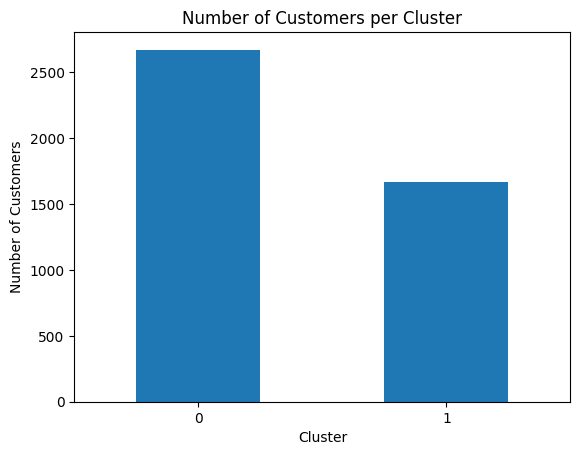

In [165]:
rfm["Cluster"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers per Cluster")
plt.xticks(rotation=0)
plt.show()

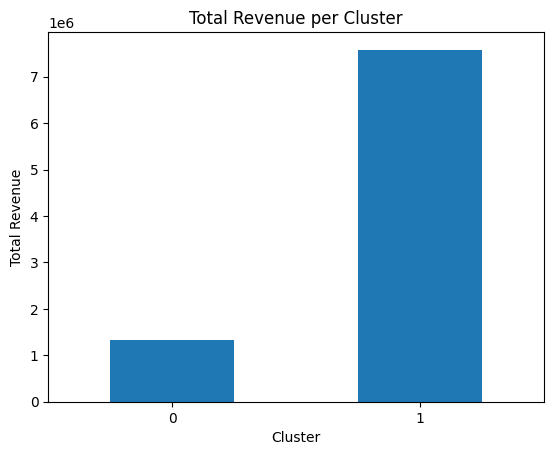

In [166]:
revenue_by_cluster = rfm.groupby("Cluster")["Monetary"].sum()

revenue_by_cluster.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Total Revenue")
plt.title("Total Revenue per Cluster")
plt.xticks(rotation=0)
plt.show()

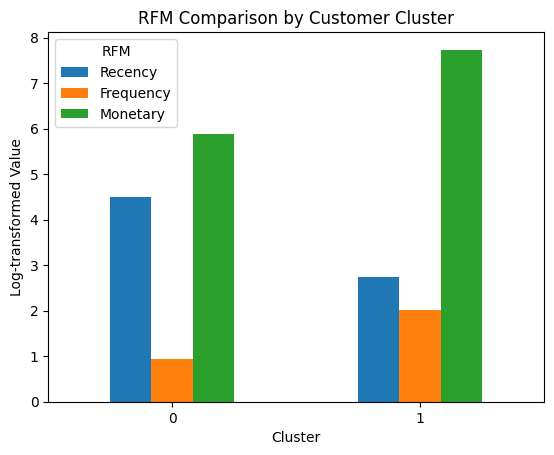

In [167]:
rfm_log_clustered = rfm_log.copy()

rfm_log_clustered["Cluster"] = rfm["Cluster"]

cluster_means = rfm_log_clustered.groupby("Cluster").mean()

cluster_means.plot(kind="bar")

plt.xlabel("Cluster")
plt.ylabel("Log-transformed Value")
plt.title("RFM Comparison by Customer Cluster")
plt.xticks(rotation=0)
plt.legend(title="RFM")
plt.show()

In [169]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("Cluster", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,
0,2671,134.135155,1.670535,497.739095,1329461.123
1,1667,25.883623,8.440312,4548.258417,7581946.781


In [178]:
final_summary = cluster_summary.copy()

In [180]:
final_summary["Segment"] = final_summary.index.map({
    0: "Low-Value / Inactive Customers",
    1: "High-Value / Active Customers"
})

In [181]:
final_summary = final_summary[
    ["Segment", "Customers", "Avg_Recency", "Avg_Frequency",
     "Avg_Monetary", "Total_Revenue"]
]

In [183]:
final_summary = final_summary.round({
    "Avg_Recency": 1,
    "Avg_Frequency": 2,
    "Avg_Monetary": 2,
    "Total_Revenue": 2
})

In [184]:
final_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Cluster,,,,,,
0,Low-Value / Inactive Customers,2671,134.1,1.67,497.74,1329461.12
1,High-Value / Active Customers,1667,25.9,8.44,4548.26,7581946.78


In [185]:
customer_share = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    / len(rfm)
    * 100
)

In [187]:
revenue_share = (
    rfm.groupby("Cluster")["Monetary"].sum()
    / rfm["Monetary"].sum()
    * 100
)

In [188]:
final_summary["Customer_Share_%"] = customer_share
final_summary["Revenue_Share_%"] = revenue_share

In [190]:
final_summary = final_summary.round({
    "Avg_Recency": 1,
    "Avg_Frequency": 2,
    "Avg_Monetary": 2,
    "Total_Revenue": 2,
    "Customer_Share_%": 1,
    "Revenue_Share_%": 1
})

final_summary

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Share_%,Revenue_Share_%
Cluster,,,,,,,,
0,Low-Value / Inactive Customers,2671,134.1,1.67,497.74,1329461.12,61.6,14.9
1,High-Value / Active Customers,1667,25.9,8.44,4548.26,7581946.78,38.4,85.1
